In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR


In [4]:
df1 = pd.read_csv('Dataset/calories.csv')
df2 = pd.read_csv('Dataset/exercise.csv')
df1.drop(columns='User_ID')
merged_df = pd.concat([df1, df2], axis=1)
merged_df.to_csv('Dataset/new_calories.csv',index=False)


In [9]:
df = pd.read_csv('Dataset/new_calories.csv')
df = df.drop(columns=['User_ID.1'])
df.head()

,User_ID,Calories,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,231.0,male,68,190,94,29,105,40.8
1,14861698,66.0,female,20,166,60,14,94,40.3
2,11179863,26.0,male,69,179,79,5,88,38.7
3,16180408,71.0,female,34,179,71,13,100,40.5
4,17771927,35.0,female,27,154,58,10,81,39.8


In [10]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])


In [11]:
x = df.drop(columns='Calories',axis=1)
y = df['Calories']
x.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,1,68,190,94,29,105,40.8
1,14861698,0,20,166,60,14,94,40.3
2,11179863,1,69,179,79,5,88,38.7
3,16180408,0,34,179,71,13,100,40.5
4,17771927,0,27,154,58,10,81,39.8


In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [13]:
models = {
    "Linear regression": LinearRegression(),
    "Ridge regression" : Ridge(),
    "Lasso regression" : Lasso(),
    "DecisionTree Regressor" : DecisionTreeRegressor(),
    "RandomForest Regressor" : RandomForestRegressor(),
    "GradientBoosting Regressor" : GradientBoostingRegressor(),
    "Support vector machine" : SVR()
}

In [14]:
results = {}
input_value = []
names = []
col  = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive']

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\

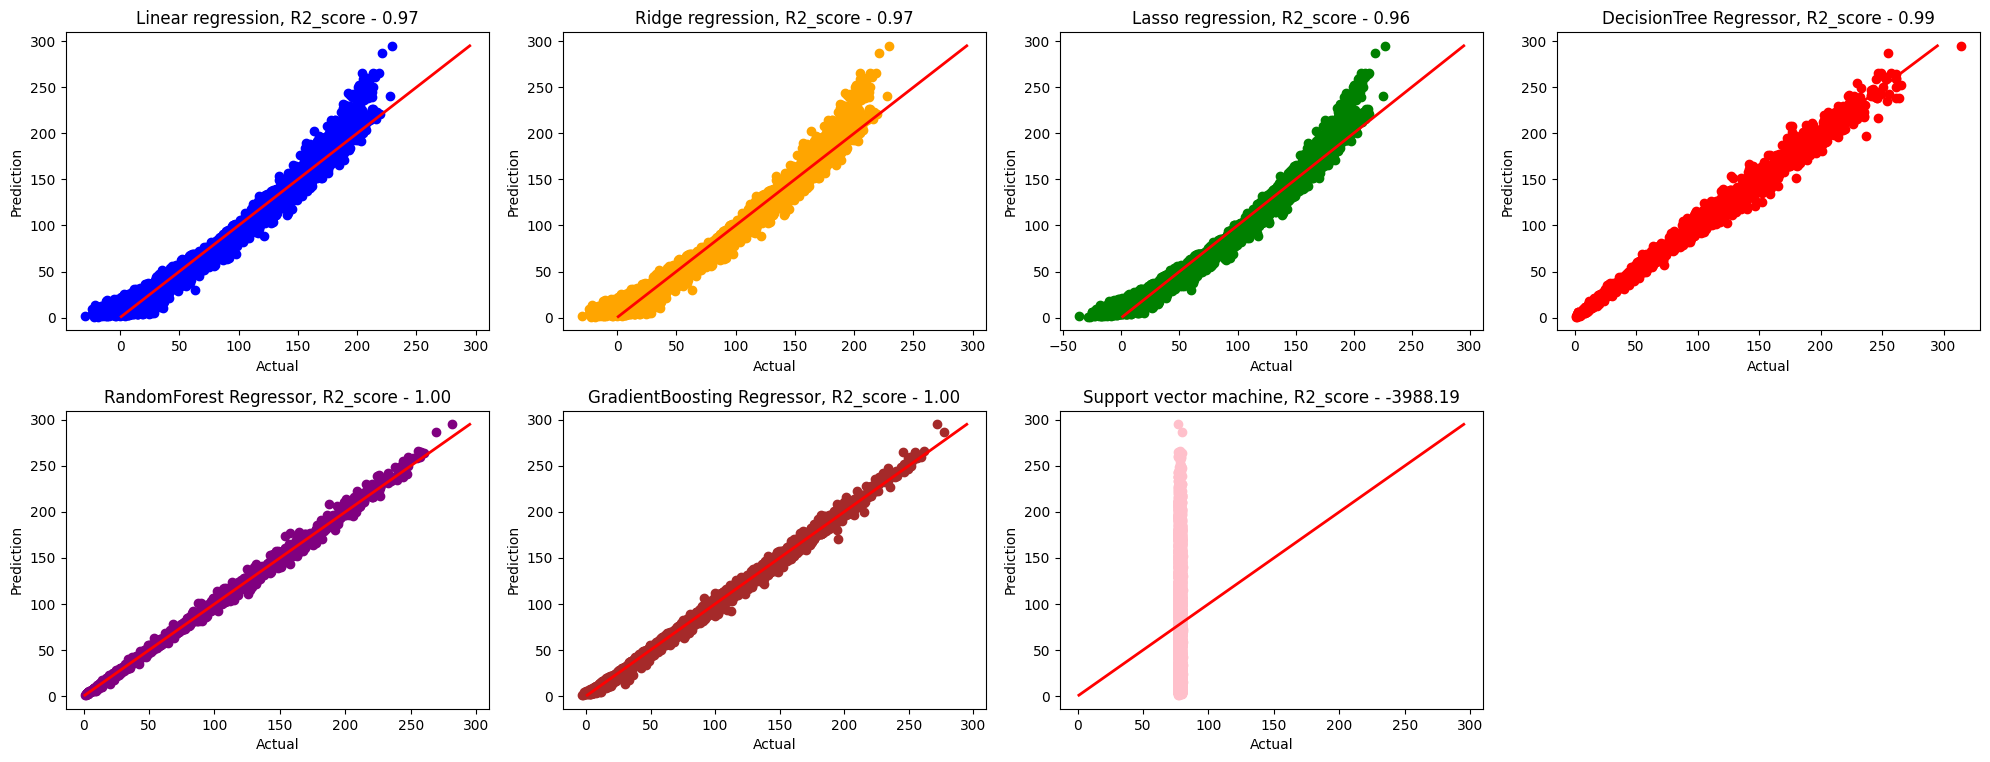

In [16]:
plt.figure(figsize=(20, 30))


for i, (name, model) in enumerate(models.items(), 1):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    mae = mean_absolute_error(y_pred, y_test)
    mse = mean_squared_error(y_pred, y_test)
    r2 = r2_score(y_pred, y_test)

    a = [[11123863,	0,	29,	279,	74,	4,	48,	38.7]]
    names.append(name)
    input_value.append(model.predict(a))

    results[name] = {
        'Mean absolute error': mae,
        'Mean square error': mse,
        'R2 score': r2
    }

    plt.subplot(8, 4, i)
    plt.scatter(y_pred, y_test, color=col[i-1])
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
    plt.title(f"{name}, R2_score - {r2:.2f}")
    plt.xlabel("Actual")
    plt.ylabel("Prediction")

plt.tight_layout()
plt.show()


In [17]:
result_df = pd.DataFrame(results).T
values = pd.DataFrame(input_value).T
name_value = pd.DataFrame(names).T
print(result_df)

values.columns = name_value.iloc[0].tolist()
print("input value reused for prediction")
print(values)

                            Mean absolute error  Mean square error  \
Linear regression                      8.443716         132.067582   
Ridge regression                       8.443610         132.068139   
Lasso regression                       8.869836         143.938529   
DecisionTree Regressor                 3.569000          29.986333   
RandomForest Regressor                 1.810037           8.051665   
GradientBoosting Regressor             2.606043          13.066166   
Support vector machine                53.819800        4216.562264   

                               R2 score  
Linear regression              0.965781  
Ridge regression               0.965780  
Lasso regression               0.962273  
DecisionTree Regressor         0.992531  
RandomForest Regressor         0.997980  
GradientBoosting Regressor     0.996733  
Support vector machine     -3988.188470  
input value reused for prediction
   Linear regression  Ridge regression  Lasso regression  \
0        